# import Library and main configuration

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_squared_error

In [2]:
color_pal = sns.color_palette()
plt.style.use("fivethirtyeight")

# EDA

In [3]:
df = pd.read_csv(r"D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\data\data_RP.csv")
df.head()

,date,price
0,1985-01-01,5205.9538
1,1985-01-02,5158.6730
2,1985-01-03,5104.6378
3,1985-01-04,5118.9909
4,1985-01-07,5036.2495


In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

In [5]:
df.head()

,price
date,
1985-01-01,5205.9538
1985-01-02,5158.6730
1985-01-03,5104.6378
1985-01-04,5118.9909
1985-01-07,5036.2495


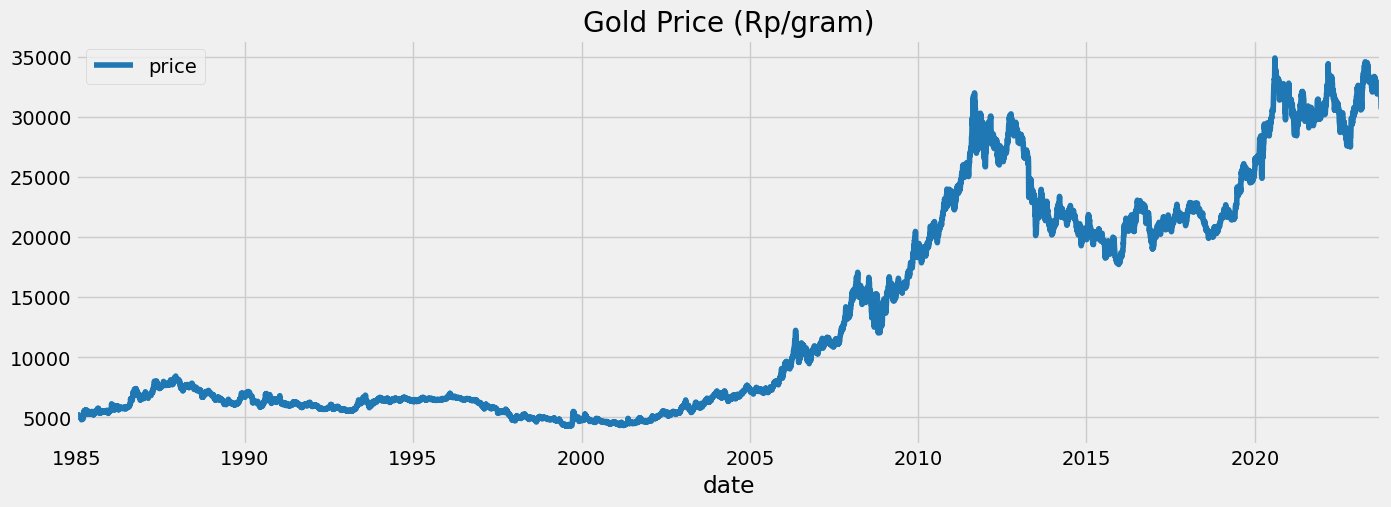

In [6]:
df.plot(
    style="-",
    figsize=(15, 5),
    color=color_pal[0],
    title="Gold Price (Rp/gram)"
)
plt.show()

In [7]:
df.isna().sum()

price    0
dtype: int64

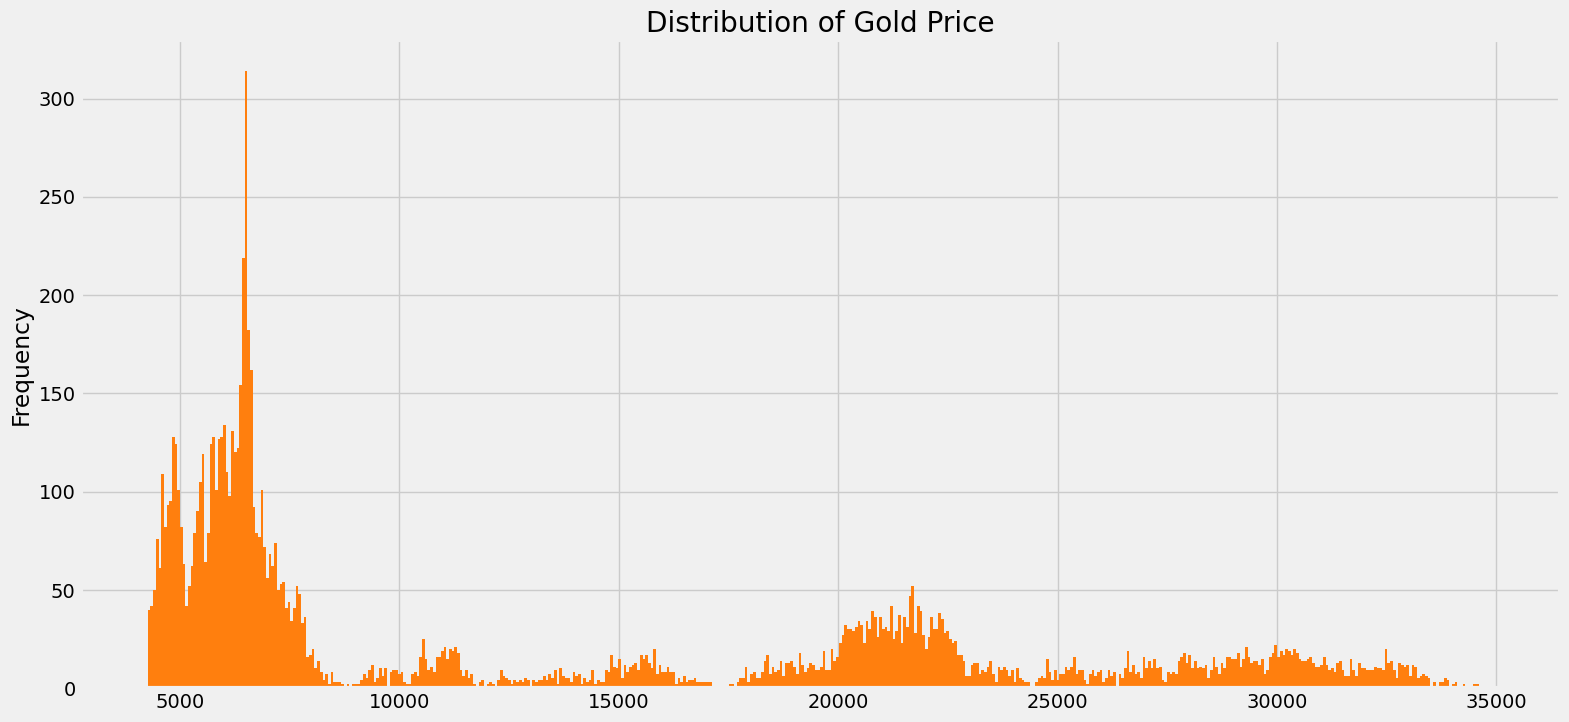

In [8]:
df['price'].plot(kind='hist', bins=500, figsize=(17, 8), color=color_pal[1], title="Distribution of Gold Price")
plt.show()

# Time Series Split

In [9]:
tss = TimeSeriesSplit(n_splits=5, test_size=365, gap=30)
df = df.sort_index()

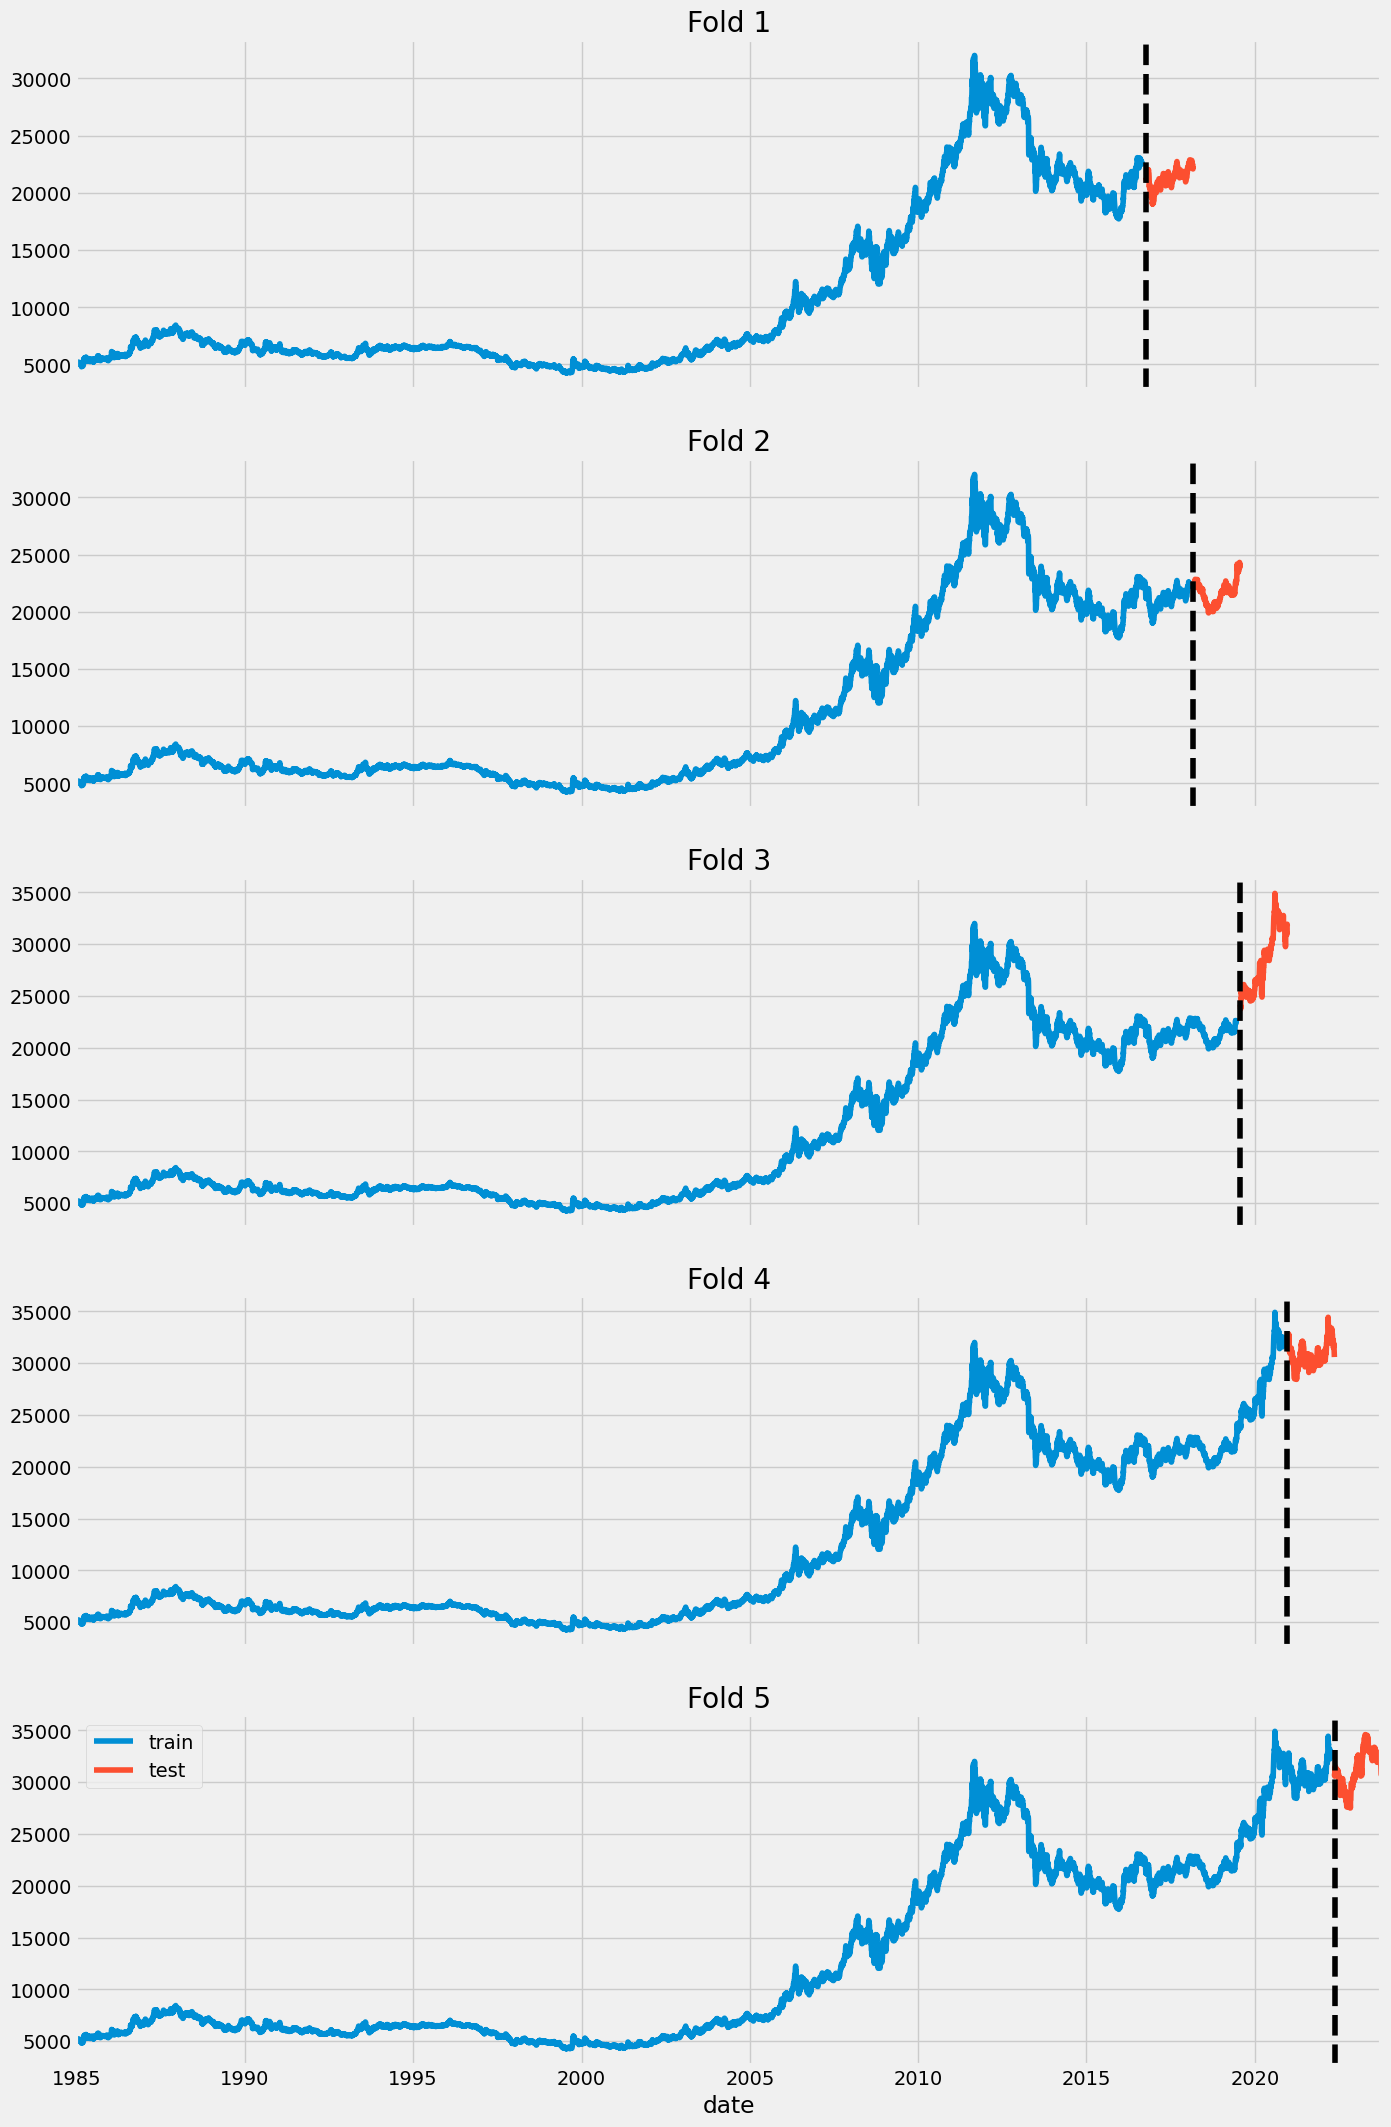

In [10]:
fig, axs = plt.subplots(5, 1, figsize=(15, 25), sharex=True)

fold = 0

for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train['price'].plot(
        ax=axs[fold],
        label='train',
        title=f"Fold {fold + 1}"
    )
    test['price'].plot(
        ax=axs[fold],
        label='test'
    ) 

    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1

plt.legend()
plt.show()   

# Feature Engineering

In [11]:
def create_feeatures(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_feeatures(df)
df.head(14)

,price,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
date,,,,,,,,
1985-01-01,5205.9538,1,1,1,1985,1,1,1
1985-01-02,5158.6730,2,1,1,1985,2,2,1
1985-01-03,5104.6378,3,1,1,1985,3,3,1
1985-01-04,5118.9909,4,1,1,1985,4,4,1
1985-01-07,5036.2495,0,1,1,1985,7,7,2
1985-01-08,5099.5720,1,1,1,1985,8,8,2
1985-01-09,5074.2430,2,1,1,1985,9,9,2
1985-01-10,5129.9668,3,1,1,1985,10,10,2
1985-01-11,5137.5655,4,1,1,1985,11,11,2


In [12]:
df['price_diff'] = df['price'].diff()
df = df.dropna().reset_index(drop=True)

In [13]:
def add_lags(df):
    df['lag1'] = df['price_diff'].shift(1)
    df['lag2'] = df['price_diff'].shift(2)
    df['lag3'] = df['price_diff'].shift(3)
    df['lag5'] = df['price_diff'].shift(5)
    df['lag21'] = df['price_diff'].shift(21)
    df['lag63'] = df['price_diff'].shift(63)
    df['lag252'] = df['price_diff'].shift(252)
    return df

df = add_lags(df)
df.head(14)

,price,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,price_diff,lag1,lag2,lag3,lag5,lag21,lag63,lag252
0,5158.6730,2,1,1,1985,2,2,1,-47.2808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5104.6378,3,1,1,1985,3,3,1,-54.0352,-47.2808,NaN,NaN,NaN,NaN,NaN,NaN
2,5118.9909,4,1,1,1985,4,4,1,14.3531,-54.0352,-47.2808,NaN,NaN,NaN,NaN,NaN
3,5036.2495,0,1,1,1985,7,7,2,-82.7414,14.3531,-54.0352,-47.2808,NaN,NaN,NaN,NaN
4,5099.5720,1,1,1,1985,8,8,2,63.3225,-82.7414,14.3531,-54.0352,NaN,NaN,NaN,NaN
5,5074.2430,2,1,1,1985,9,9,2,-25.3290,63.3225,-82.7414,14.3531,-47.2808,NaN,NaN,NaN
6,5129.9668,3,1,1,1985,10,10,2,55.7238,-25.3290,63.3225,-82.7414,-54.0352,NaN,NaN,NaN
7,5137.5655,4,1,1,1985,11,11,2,7.5987,55.7238,-25.3290,63.3225,14.3531,NaN,NaN,NaN
8,5048.9140,0,1,1,1985,14,14,3,-88.6515,7.5987,55.7238,-25.3290,-82.7414,NaN,NaN,NaN
9,5096.1948,1,1,1,1985,15,15,3,47.2808,-88.6515,7.5987,55.7238,63.3225,NaN,NaN,NaN


In [14]:
def add_rolling_windows(df):
    df = df.copy()

    df['rolling_mean_7'] = df['price_diff'].shift(1).rolling(window=7).mean()
    df['rolling_mean_30'] = df['price_diff'].shift(1).rolling(window=30).mean()

    df['rolling_std_7'] = df['price_diff'].shift(1).rolling(window=7).std()
    df['rolling_std_30'] = df['price_diff'].shift(1).rolling(window=30).std()

    df['rolling_max_7'] = df['price_diff'].shift(1).rolling(window=7).max()
    df['rolling_min_7'] = df['price_diff'].shift(1).rolling(window=7).min()

    return df

df = add_rolling_windows(df)
df.head(14)
    

,price,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,price_diff,lag1,...,lag5,lag21,lag63,lag252,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,rolling_max_7,rolling_min_7
0,5158.6730,2,1,1,1985,2,2,1,-47.2808,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5104.6378,3,1,1,1985,3,3,1,-54.0352,-47.2808,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5118.9909,4,1,1,1985,4,4,1,14.3531,-54.0352,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5036.2495,0,1,1,1985,7,7,2,-82.7414,14.3531,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5099.5720,1,1,1,1985,8,8,2,63.3225,-82.7414,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5074.2430,2,1,1,1985,9,9,2,-25.3290,63.3225,...,-47.2808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,5129.9668,3,1,1,1985,10,10,2,55.7238,-25.3290,...,-54.0352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,5137.5655,4,1,1,1985,11,11,2,7.5987,55.7238,...,14.3531,NaN,NaN,NaN,-10.855286,NaN,56.478619,NaN,63.3225,-82.7414
8,5048.9140,0,1,1,1985,14,14,3,-88.6515,7.5987,...,-82.7414,NaN,NaN,NaN,-3.015357,NaN,54.348392,NaN,63.3225,-82.7414
9,5096.1948,1,1,1,1985,15,15,3,47.2808,-88.6515,...,63.3225,NaN,NaN,NaN,-7.960543,NaN,60.939624,NaN,63.3225,-88.6515


In [15]:
df.shape[0], df.shape[0] - df.isna().sum().sum()

(10113, 9678)

In [16]:
df.isna().sum()

price                0
dayofweek            0
quarter              0
month                0
year                 0
dayofyear            0
dayofmonth           0
weekofyear           0
price_diff           0
lag1                 1
lag2                 2
lag3                 3
lag5                 5
lag21               21
lag63               63
lag252             252
rolling_mean_7       7
rolling_mean_30     30
rolling_std_7        7
rolling_std_30      30
rolling_max_7        7
rolling_min_7        7
dtype: int64

In [17]:
df.dropna(inplace=True)
df.isna().sum()

price              0
dayofweek          0
quarter            0
month              0
year               0
dayofyear          0
dayofmonth         0
weekofyear         0
price_diff         0
lag1               0
lag2               0
lag3               0
lag5               0
lag21              0
lag63              0
lag252             0
rolling_mean_7     0
rolling_mean_30    0
rolling_std_7      0
rolling_std_30     0
rolling_max_7      0
rolling_min_7      0
dtype: int64

In [18]:
df.shape

(9861, 22)

# Modelling

In [19]:
df = df.sort_index()

fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    FEATURES = [col for col in df.columns if col not in ['price', 'price_diff']]
    TARGET = 'price_diff'

    x_train, y_train = train[FEATURES], train[TARGET]
    x_test, y_test = test[FEATURES], test[TARGET]

    model = XGBRegressor(
        base_score=0.5,
        booster='gbtree',
        n_estimators=1000,
        objective='reg:squarederror',
        learning_rate=0.01,
        max_depth=2,
        colsample_bytree=0.7,
        random_state=42
    )

    model.fit(
        x_train, y_train,
        eval_set=[(x_train, y_train), (x_test, y_test)],
        verbose=100
    )

    y_pred = model.predict(x_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[0]	validation_0-rmse:147.64716	validation_1-rmse:148.40765
[100]	validation_0-rmse:146.28157	validation_1-rmse:148.41367
[200]	validation_0-rmse:145.15713	validation_1-rmse:148.45209
[300]	validation_0-rmse:144.14946	validation_1-rmse:148.55139
[400]	validation_0-rmse:143.23008	validation_1-rmse:148.61528
[500]	validation_0-rmse:142.39913	validation_1-rmse:148.74327
[600]	validation_0-rmse:141.67170	validation_1-rmse:149.14441
[700]	validation_0-rmse:140.92235	validation_1-rmse:149.39290
[800]	validation_0-rmse:140.25842	validation_1-rmse:149.62837
[900]	validation_0-rmse:139.57290	validation_1-rmse:149.91923
[999]	validation_0-rmse:138.96414	validation_1-rmse:150.25396
[0]	validation_0-rmse:147.80446	validation_1-rmse:132.07406
[100]	validation_0-rmse:146.51775	validation_1-rmse:132.36398
[200]	validation_0-rmse:145.49612	validation_1-rmse:132.46937
[300]	validation_0-rmse:144.53645	validation_1-rmse:132.55750
[400]	validation_0-rmse:143.64264	validation_1-rmse:132.64992
[500]	valida

In [20]:
print(f"Score across folds: {np.mean(scores):0.4f}")
print(f'Fold scores:{scores}')

Score across folds: 232.5142
Fold scores:[150.2539602882733, 132.9621235090055, 332.7701617142305, 297.0560682963585, 249.5286522051077]


Score across folds: 620.6316

Score across folds: 501.3704

Score across folds: 476.7431

Score across folds: 443.9370

# Interpretation

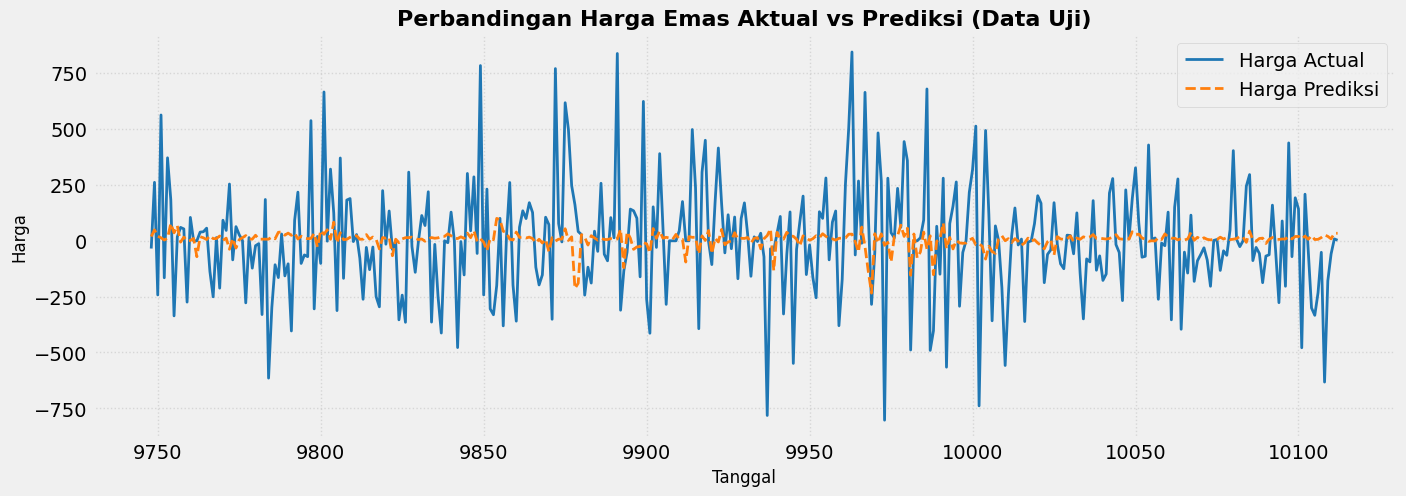

In [21]:
plt.figure(figsize=(15, 5))

plt.plot(y_test.index, y_test.values, label='Harga Actual', color=color_pal[0], linewidth=2)
plt.plot(y_test.index, y_pred, label='Harga Prediksi', color=color_pal[1], linewidth=2, linestyle='--')

plt.title('Perbandingan Harga Emas Aktual vs Prediksi (Data Uji)', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

C:\Users\aryag\AppData\Local\Temp\ipykernel_25844\3644440010.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y=fi_sorted.index, data=fi_sorted, palette='viridis')


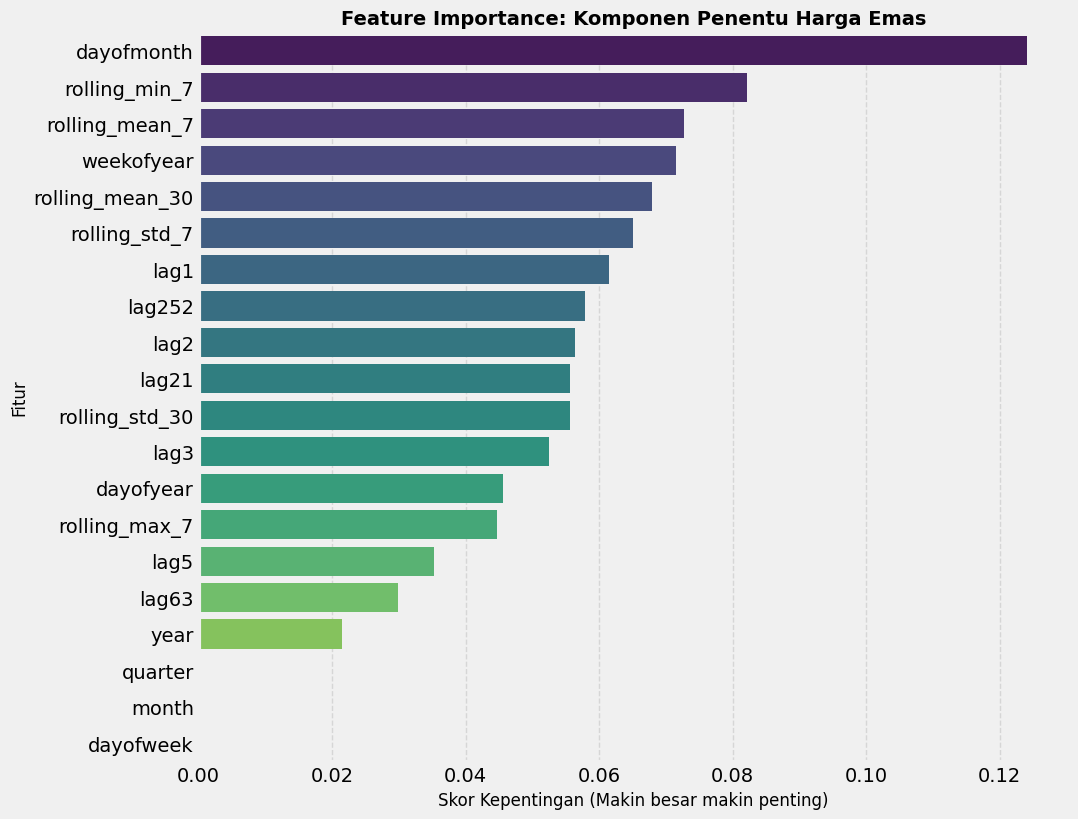

In [22]:
fi = pd.DataFrame(
    data=model.feature_importances_,
    index=model.feature_names_in_,
    columns=['importance']
)

fi_sorted = fi.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 9))
sns.barplot(x='importance', y=fi_sorted.index, data=fi_sorted, palette='viridis')

plt.title('Feature Importance: Komponen Penentu Harga Emas', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kepentingan (Makin besar makin penting)', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()


In [23]:
model_filename = r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\artifacts\xgboost.json'
model.save_model(model_filename)
print(f"Model XGBoost telah disimpan sebagai '{model_filename}'")

Model XGBoost telah disimpan sebagai 'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\artifacts\xgboost.json'


In [24]:
train.reset_index(inplace=True)
train.head()

,index,price,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,price_diff,...,lag5,lag21,lag63,lag252,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,rolling_max_7,rolling_min_7
0,252,5497.2373,4,4,12,1985,354,20,51,-4.2215,...,4.2215,2.5329,7.5987,-47.2808,21.228114,1.576027,41.789093,36.098644,97.0945,-25.3290
1,253,5531.8536,0,4,12,1985,357,23,52,34.6163,...,14.3531,11.8202,10.1316,-54.0352,24.243471,2.026320,38.502037,35.933389,97.0945,-18.5746
2,254,5485.4171,1,4,12,1985,358,24,52,-46.4365,...,43.0593,62.4782,12.6645,14.3531,24.364086,2.532900,38.538168,36.292372,97.0945,-18.5746
3,255,5485.4171,2,4,12,1985,359,25,52,0.0000,...,-18.5746,17.7303,-10.9759,-82.7414,17.127229,0.985017,46.817975,37.378152,97.0945,-46.4365
4,256,5485.4171,3,4,12,1985,360,26,52,0.0000,...,97.0945,-52.3466,-48.1251,63.3225,15.076786,0.197003,47.271825,37.132445,97.0945,-46.4365


In [25]:
test.reset_index(inplace=True)
test.head()

,index,price,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,price_diff,...,lag5,lag21,lag63,lag252,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,rolling_max_7,rolling_min_7
0,9748,30555.2170,0,2,5,2022,136,16,20,-34.6163,...,-362.2047,0.0000,237.2483,-140.1538,-125.680086,-66.333837,300.976639,281.855101,483.7839,-430.593
1,9749,30816.9500,1,2,5,2022,137,17,20,261.7330,...,-59.9453,0.0000,520.9331,143.5310,-199.737257,-67.994293,153.827086,281.504737,-34.6163,-430.593
2,9750,30574.6359,2,2,5,2022,138,18,20,-242.3141,...,-91.1844,12.6645,2.5329,0.0000,-138.344586,-67.009277,233.645656,282.640716,261.7330,-430.593
3,9751,31137.7840,3,2,5,2022,139,19,20,563.1481,...,-251.6014,-244.0027,14.3531,-10.1316,-121.217357,-67.262567,218.397448,282.799549,261.7330,-430.593
4,9752,30972.3012,4,2,5,2022,140,20,20,-165.4828,...,-430.5930,-98.7831,95.4059,57.4124,-32.204014,-49.757413,340.422007,304.927229,563.1481,-430.593


In [26]:
# train.to_csv(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\data\train.csv', index=False)
# test.to_csv(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\data\test.csv', index=False)

In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [3]:
model_xgb = XGBRegressor()
model_xgb.load_model(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\artifacts\xgboost.json')

In [4]:
test_df = pd.read_csv(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\data\test.csv')
test_df.head()

,date,price,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,lag5,lag21,lag63,lag252,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,rolling_max_7,rolling_min_7
0,2022-05-16,30555.2170,0,2,5,2022,136,16,20,30589.8333,31020.4263,31272.0277,31423.1574,33151.4395,31451.8636,31939.0247,31343.913814,32296.895327,456.695397,747.730819,31953.3778,30589.8333
1,2022-05-17,30816.9500,1,2,5,2022,137,17,20,30555.2170,30589.8333,31020.4263,31363.2121,33151.4395,31972.7967,32082.5557,31144.176557,32228.901033,451.433943,809.848707,31785.3621,30555.2170
2,2022-05-18,30574.6359,2,2,5,2022,138,18,20,30816.9500,30555.2170,30589.8333,31272.0277,33164.1040,31975.3296,32082.5557,31005.831971,32161.891757,361.648857,841.195697,31423.1574,30555.2170
3,2022-05-19,31137.7840,3,2,5,2022,139,19,20,30574.6359,30816.9500,30555.2170,31020.4263,32920.1013,31989.6827,32072.4241,30884.614614,32094.629190,340.013083,885.104997,31363.2121,30555.2170
4,2022-05-20,30972.3012,4,2,5,2022,140,20,20,31137.7840,30574.6359,30816.9500,30589.8333,32821.3182,32085.0886,32129.8365,30852.410600,32044.871777,294.797353,895.833827,31272.0277,30555.2170


In [7]:
test_df['price_diff'] = test_df['price'].diff()
test_df = test_df.dropna().reset_index(drop=True)
test_df.head()

,date,price,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,lag5,lag21,lag63,lag252,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,rolling_max_7,rolling_min_7,price_diff
0,2022-05-17,30816.9500,1,2,5,2022,137,17,20,30555.2170,30589.8333,31020.4263,31363.2121,33151.4395,31972.7967,32082.5557,31144.176557,32228.901033,451.433943,809.848707,31785.3621,30555.217,261.7330
1,2022-05-18,30574.6359,2,2,5,2022,138,18,20,30816.9500,30555.2170,30589.8333,31272.0277,33164.1040,31975.3296,32082.5557,31005.831971,32161.891757,361.648857,841.195697,31423.1574,30555.217,-242.3141
2,2022-05-19,31137.7840,3,2,5,2022,139,19,20,30574.6359,30816.9500,30555.2170,31020.4263,32920.1013,31989.6827,32072.4241,30884.614614,32094.629190,340.013083,885.104997,31363.2121,30555.217,563.1481
3,2022-05-20,30972.3012,4,2,5,2022,140,20,20,31137.7840,30574.6359,30816.9500,30589.8333,32821.3182,32085.0886,32129.8365,30852.410600,32044.871777,294.797353,895.833827,31272.0277,30555.217,-165.4828
4,2022-05-23,31343.7932,0,2,5,2022,143,23,21,30972.3012,31137.7840,30574.6359,30555.2170,32785.0133,32162.7642,31518.5633,30809.592529,31984.532470,240.449028,905.350863,31137.7840,30555.217,371.4920


In [8]:
if 'date' in test_df.columns:
    test_df = test_df.sort_values('date').reset_index(drop=True)

FEATURES = [col for col in test_df.columns if col not in ['price', 'price_diff', 'date']]
x_test = test_df[FEATURES]
x_test.head()

,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,lag5,lag21,lag63,lag252,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,rolling_max_7,rolling_min_7
0,1,2,5,2022,137,17,20,30555.2170,30589.8333,31020.4263,31363.2121,33151.4395,31972.7967,32082.5557,31144.176557,32228.901033,451.433943,809.848707,31785.3621,30555.217
1,2,2,5,2022,138,18,20,30816.9500,30555.2170,30589.8333,31272.0277,33164.1040,31975.3296,32082.5557,31005.831971,32161.891757,361.648857,841.195697,31423.1574,30555.217
2,3,2,5,2022,139,19,20,30574.6359,30816.9500,30555.2170,31020.4263,32920.1013,31989.6827,32072.4241,30884.614614,32094.629190,340.013083,885.104997,31363.2121,30555.217
3,4,2,5,2022,140,20,20,31137.7840,30574.6359,30816.9500,30589.8333,32821.3182,32085.0886,32129.8365,30852.410600,32044.871777,294.797353,895.833827,31272.0277,30555.217
4,0,2,5,2022,143,23,21,30972.3012,31137.7840,30574.6359,30555.2170,32785.0133,32162.7642,31518.5633,30809.592529,31984.532470,240.449028,905.350863,31137.7840,30555.217


In [9]:
import pandas as pd

# ==============================================================
# 1. LOAD DATA MENTAH KESELURUHAN (TRAIN + TEST BELUM DI-SPLIT)
# ==============================================================
# Asumsi Anda punya data mentah historis lengkap
df_all = pd.read_csv(r'D:\AI AND DATA SCIENCE\Time Series\Kencana Oracle\data\test.csv') 

# Ambil HANYA kolom date dan price, buang fitur-fitur absolut yang lama
df_all = df_all[['date', 'price']].copy()
df_all['date'] = pd.to_datetime(df_all['date'])
df_all = df_all.sort_values('date').reset_index(drop=True)

# ==============================================================
# 2. LAKUKAN DIFFERENCING DAN FEATURE ENGINEERING
# ==============================================================
# Buat target selisih harga
df_all['price_diff'] = df_all['price'].diff()

# Buat Time Features
df_all['dayofweek'] = df_all['date'].dt.dayofweek
df_all['quarter'] = df_all['date'].dt.quarter
df_all['month'] = df_all['date'].dt.month
df_all['year'] = df_all['date'].dt.year
df_all['dayofyear'] = df_all['date'].dt.dayofyear
df_all['dayofmonth'] = df_all['date'].dt.day
df_all['weekofyear'] = df_all['date'].dt.isocalendar().week.astype(int)

# Buat Lag Features (Versi Diff)
lags = [1, 2, 3, 5, 21, 63, 252]
for lag in lags:
    df_all[f'lag{lag}'] = df_all['price_diff'].shift(lag)

# Buat Rolling Features (Versi Diff)
df_all['rolling_mean_7'] = df_all['price_diff'].shift(1).rolling(window=7).mean()
df_all['rolling_mean_30'] = df_all['price_diff'].shift(1).rolling(window=30).mean()
df_all['rolling_std_7'] = df_all['price_diff'].shift(1).rolling(window=7).std()
df_all['rolling_std_30'] = df_all['price_diff'].shift(1).rolling(window=30).std()
df_all['rolling_max_7'] = df_all['price_diff'].shift(1).rolling(window=7).max()
df_all['rolling_min_7'] = df_all['price_diff'].shift(1).rolling(window=7).min()

# Buang baris NaN akibat shift(252)
df_clean = df_all.dropna().reset_index(drop=True)

# ==============================================================
# 3. POTONG KEMBALI HANYA UNTUK DATA TEST
# ==============================================================
# Misal, data test Anda adalah data dari tahun 2022 ke atas (sesuaikan dengan kondisi Anda)
# Atau jika Anda tahu tanggal pasti awal data test Anda:

FEATURES = [
    'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear',
    'lag1', 'lag2', 'lag3', 'lag5', 'lag21', 'lag63', 'lag252',
    'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7', 'rolling_std_30', 
    'rolling_max_7', 'rolling_min_7'
]

# Ini x_test yang BENAR untuk dimasukkan ke model
x_test = df_clean[FEATURES]

display(x_test.head())

,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,lag5,lag21,lag63,lag252,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,rolling_max_7,rolling_min_7
0,3,2,5,2023,124,4,18,319.1454,216.9851,0.0000,-292.9721,358.8275,-35.4606,261.7330,87.083514,36.558190,215.232163,334.711015,319.1454,-292.9721
1,4,2,5,2023,125,5,18,513.3344,319.1454,216.9851,-52.3466,-488.8497,-43.0593,-242.3141,138.223971,37.571350,269.774974,336.151692,513.3344,-292.9721
2,0,2,5,2023,128,8,19,-738.7625,513.3344,319.1454,0.0000,0.0000,32.9277,563.1481,-4.945186,4.024497,417.656197,361.650448,513.3344,-738.7625
3,1,2,5,2023,129,9,19,0.0000,-738.7625,513.3344,216.9851,0.0000,108.9147,-165.4828,36.907971,30.788807,398.209186,328.018726,513.3344,-738.7625
4,2,2,5,2023,130,10,19,493.9155,0.0000,-738.7625,319.1454,13.5088,-327.5884,371.4920,114.945414,37.909070,430.055024,335.846744,513.3344,-738.7625


In [14]:
df_clean['pred_diff'] = model_xgb.predict(x_test)

In [15]:
df_clean['harga_asli_kemarin'] = df_clean['price'] - df_clean['price_diff']

In [16]:
df_clean['pred_absolute'] = df_clean['harga_asli_kemarin'] + df_clean['pred_diff']

In [17]:
y_true = df_clean['price']
y_pred = df_clean['pred_absolute']

In [18]:
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print("-" * 35)
print("📊 HASIL EVALUASI XGBOOST (HARGA ASLI)")
print("-" * 35)
print(f"MAE  : Rp {mae:,.2f}")
print(f"RMSE : Rp {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")
print("-" * 35)

display(df_clean[['date', 'harga_asli_kemarin', 'pred_diff', 'pred_absolute', 'price']].head())

-----------------------------------
📊 HASIL EVALUASI XGBOOST (HARGA ASLI)
-----------------------------------
MAE  : Rp 158.75
RMSE : Rp 217.95
MAPE : 0.48%
-----------------------------------


,date,harga_asli_kemarin,pred_diff,pred_absolute,price
0,2023-05-04,34013.4698,-17.802792,33995.667008,34526.8042
1,2023-05-05,34526.8042,-12.951957,34513.852243,33788.0417
2,2023-05-08,33788.0417,-24.749556,33763.292144,33788.0417
3,2023-05-09,33788.0417,-81.783073,33706.258627,34281.9572
4,2023-05-10,34281.9572,-24.305269,34257.651931,34399.3149
